In [ ]:
!pip install transformers
!pip install pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import string
import warnings
from tqdm.auto import tqdm
import torch
from transformers import BertTokenizer, BertForSequenceClassification, get_scheduler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Skripsi/data_prepro_labeled.csv')
df

,full_text,text_clean,text_casefolding,text_token,text_normalize,text_stopwords,text,Label_ID,Confidence_Score,Sentimen,Label_fine_tuned,Confidence_fine_tuned,sentimen_fine_tuned
0,@DS_yantie Lah itu MBG apakabar??? Pak pak,Lah itu MBG apakabar Pak pak,lah itu mbg apakabar pak pak,"['lah', 'itu', 'mbg', 'apakabar', 'pak', 'pak']","['lah', 'itu', 'mbg', 'apakabar', 'pak', 'pak']","['mbg', 'apakabar']",mbg apakabar,2,0.503783,Negatif,2,0.935089,Negatif
1,MBG anak sehat Indonesia hebat #FaktaIndonesia...,MBG anak sehat Indonesia hebat,mbg anak sehat indonesia hebat,"['mbg', 'anak', 'sehat', 'indonesia', 'hebat']","['mbg', 'anak', 'sehat', 'indonesia', 'hebat']","['mbg', 'anak', 'sehat', 'indonesia', 'hebat']",mbg anak sehat indonesia hebat,0,0.995272,Positif,0,0.947168,Positif
2,Pentingnya program MBG untuk masa depan #Fakta...,Pentingnya program MBG untuk masa depan,pentingnya program mbg untuk masa depan,"['pentingnya', 'program', 'mbg', 'untuk', 'mas...","['pentingnya ', 'program', 'mbg', 'untuk', 'm...","['pentingnya ', 'program', 'mbg']",pentingnya program mbg,1,0.665221,Netral,0,0.542193,Positif
3,MBG adalah langkah nyata membangun generasi se...,MBG adalah langkah nyata membangun generasi sehat,mbg adalah langkah nyata membangun generasi sehat,"['mbg', 'adalah', 'langkah', 'nyata', 'membang...","['mbg', 'adalah', 'langkah', 'nyata', 'membang...","['mbg', 'langkah', 'nyata', 'membangun', 'gene...",mbg langkah nyata membangun generasi sehat,0,0.528011,Positif,0,0.905261,Positif
4,@komaria_cocom MBG anakku loh kak bikin ngelus...,MBG anakku loh kak bikin ngelus dada Buat hari...,mbg anakku loh kak bikin ngelus dada buat hari...,"['mbg', 'anakku', 'loh', 'kak', 'bikin', 'ngel...","['mbg', 'anakku', 'kok', 'kak', 'buat', 'ngelu...","['mbg', 'anakku', 'kak', 'ngelus', 'dada', 'sa...",mbg anakku kak ngelus dada salak susu uht kota...,1,0.990892,Netral,1,0.526549,Netral
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7357,Naahh!! Dengan adanya program MBG anak-anak ga...,Naahh Dengan adanya program MBG anakanak gaj p...,naahh dengan adanya program mbg anakanak gaj p...,"['naahh', 'dengan', 'adanya', 'program', 'mbg'...","['naahh', 'dengan', 'adanya', 'program', 'mbg'...","['naahh', 'program', 'mbg', 'anakanak', 'gaj',...",naahh program mbg anakanak gaj membeli makanan...,0,0.979206,Positif,0,0.767132,Positif
7358,@ranie__14 @endahm7 @Dandhy_Laksono yang dimak...,yang dimaksudkan itu program MBG di daerah yan...,yang dimaksudkan itu program mbg di daerah yan...,"['yang', 'dimaksudkan', 'itu', 'program', 'mbg...","['yang', 'dimaksudkan', 'itu', 'program', 'mbg...","['program', 'mbg', 'daerah', 'terpapar', 'penc...",program mbg daerah terpapar pencemaran logam b...,2,0.661973,Negatif,2,0.924340,Negatif
7359,Pertemuan Prabowo-Macron Bahas Isu MBG hingga ...,Pertemuan PrabowoMacron Bahas Isu MBG hingga A...,pertemuan prabowomacron bahas isu mbg hingga a...,"['pertemuan', 'prabowomacron', 'bahas', 'isu',...","['pertemuan', 'prabowomacron', 'bahas', 'isu',...","['pertemuan', 'prabowomacron', 'bahas', 'isu',...",pertemuan prabowomacron bahas isu mbg alutsista,1,0.996780,Netral,1,0.979394,Netral
7360,@txtdrimedia Yg dikasih MBG jutaan siswa kalan...,Yg dikasih MBG jutaan siswa kalangan SDSMA Buk...,yg dikasih mbg jutaan siswa kalangan sdsma buk...,"['yg', 'dikasih', 'mbg', 'jutaan', 'siswa', 'k...","['yang', 'dikasih', 'mbg', 'jutaan', 'siswa', ...","['dikasih', 'mbg', 'jutaan', 'siswa', 'kalanga...",dikasih mbg jutaan siswa kalangan sdsma bukti ...,2,0.965784,Negatif,2,0.651894,Negatif


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7362 entries, 0 to 7361
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   full_text              7362 non-null   object 
 1   text_clean             7362 non-null   object 
 2   text_casefolding       7362 non-null   object 
 3   text_token             7362 non-null   object 
 4   text_normalize         7362 non-null   object 
 5   text_stopwords         7362 non-null   object 
 6   text                   7362 non-null   object 
 7   Label_ID               7362 non-null   int64  
 8   Confidence_Score       7362 non-null   float64
 9   Sentimen               7362 non-null   object 
 10  Label_fine_tuned       7362 non-null   int64  
 11  Confidence_fine_tuned  7362 non-null   float64
 12  sentimen_fine_tuned    7362 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 747.8+ KB


In [ ]:
# Menampilkan jumlah masing-masing sentimen
sentimen_count = df['sentimen_fine_tuned'].value_counts()
print(sentimen_count)

sentimen_fine_tuned
Negatif    4004
Netral     1866
Positif    1492
Name: count, dtype: int64


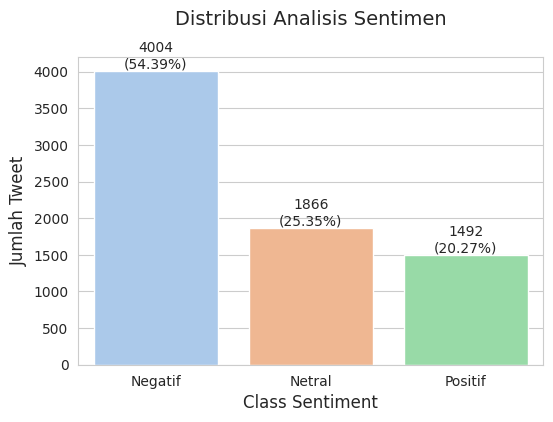

In [ ]:
sentimen_count = df['sentimen_fine_tuned'].value_counts()
sns.set_style('whitegrid')
fig,ax=plt.subplots(figsize=(6,4))
ax = sns.barplot(x=sentimen_count.index, y=sentimen_count.values, palette='pastel')
plt.title('Distribusi Analisis Sentimen', fontsize=14, pad=23)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)
total = len(df['sentimen_fine_tuned'])

for i, count in enumerate(sentimen_count.values):
  percentage = f'{100*count/total:.2f}%'
  ax.text(i, count + 0.10, f'{count}\n({percentage})' , ha='center', va='bottom')

plt.show()

# Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

X = df['text']
# Change y to use 'sentimen_fine_tuned'
y = df['Label_fine_tuned'] # Use 'sentimen_fine_tuned' column

# Split the data into training and testing sets (80% train, 20% test)
# Use the encoded labels y_encoded
# Split the data while keeping track of original indices
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y # Stratify to maintain class distribution
)

print(f' Jumlah data training: {len(X_train)}')
print(f' Jumlah data testing: {len(X_test)}')

 Jumlah data training: 5889
 Jumlah data testing: 1473


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# ========================================
# STEP 1: TRAIN-TEST SPLIT
# ========================================
print("="*60)
print("STEP 1: TRAIN-TEST SPLIT")
print("="*60)

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Label_fine_tuned']
)
print()

# ========================================
# STEP 2: UNDERSAMPLE TRAINING DATA ONLY
# ========================================
print("="*60)
print("STEP 2: UNDERSAMPLING (Training Set Only)")
print("="*60)

train_negative = train_df[train_df['Label_fine_tuned'] == 2]
train_neutral = train_df[train_df['Label_fine_tuned'] == 1]
train_positive = train_df[train_df['Label_fine_tuned'] == 0]

print("Distribusi kelas di DATA TRAIN sebelum undersampling:")
print(f"  Negatif (2): {len(train_negative)}")
print(f"  Netral (1):  {len(train_neutral)}")
print(f"  Positif (0): {len(train_positive)}")

min_class_count = min(len(train_negative), len(train_neutral), len(train_positive))
print(f"\nJumlah kelas minoritas: {min_class_count}")
print(f"Undersampling semua kelas menjadi: {min_class_count} sampel masing-masing")

train_undersampled = pd.concat([
    resample(train_negative, replace=False, n_samples=min_class_count, random_state=42),
    resample(train_neutral, replace=False, n_samples=min_class_count, random_state=42),
    resample(train_positive, replace=False, n_samples=min_class_count, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribusi kelas di DATA TRAIN setelah undersampling:")
print(train_undersampled['Label_fine_tuned'].value_counts())
print()

# ========================================
# STEP 3: EXTRACT FINAL X AND Y
# ========================================
print("="*60)
print("STEP 3: EXTRACTING FINAL DATA")
print("="*60)

X_train = train_undersampled['text'].astype(str).values
y_train = train_undersampled['Label_fine_tuned'].values

X_test = test_df['text'].astype(str).values
y_test = test_df['Label_fine_tuned'].values

print(f"X_train size: {len(X_train)}")
print(f"y_train size: {len(y_train)}")
print(f"X_test size:  {len(X_test)}")
print(f"y_test size:  {len(y_test)}")
print()

# ========================================
# STEP 4: FINAL VERIFICATION
# ========================================
print("="*60)
print("STEP 4: FINAL VERIFICATION")
print("="*60)

# Check : Text content overlap
train_texts_set = set(X_train)
test_texts_set = set(X_test)
text_overlap = train_texts_set.intersection(test_texts_set)

print(f"Unique texts in train: {len(train_texts_set)}")
print(f"Unique texts in test:  {len(test_texts_set)}")
print(f"Text content overlap:  {len(text_overlap)}")

# Final verdict
print()
if len(text_overlap) == 0:
    print("✅✅✅ PERFECT! No text overlap!")
    print("✅ Dataset is clean and ready for training")
else:
    print(f"⚠️ {len(text_overlap)} duplicate texts found")

print("="*60)
print()

# ========================================
# SUMMARY
# ========================================
print("="*60)
print("SUMMARY")
print("="*60)
print(f"Original dataset (preprocessed): {len(df)} samples")
print(f"Training (undersampled):         {len(X_train)} samples")
print(f"Testing:                         {len(X_test)} samples")
print("="*60)

STEP 1: TRAIN-TEST SPLIT

STEP 2: UNDERSAMPLING (Training Set Only)
Distribusi kelas di DATA TRAIN sebelum undersampling:
  Negatif (2): 3203
  Netral (1):  1493
  Positif (0): 1193

Jumlah kelas minoritas: 1193
Undersampling semua kelas menjadi: 1193 sampel masing-masing

Distribusi kelas di DATA TRAIN setelah undersampling:
Label_fine_tuned
2    1193
0    1193
1    1193
Name: count, dtype: int64

STEP 3: EXTRACTING FINAL DATA
X_train size: 3579
y_train size: 3579
X_test size:  1473
y_test size:  1473

STEP 4: FINAL VERIFICATION
Unique texts in train: 3579
Unique texts in test:  1473
Text content overlap:  0

✅✅✅ PERFECT! No text overlap!
✅ Dataset is clean and ready for training

SUMMARY
Original dataset (preprocessed): 7362 samples
Training (undersampled):         3579 samples
Testing:                         1473 samples


# TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 1. Apply TF-IDF to the training data
# Using default parameters for now (unigrams, max_features=None)
# You can adjust max_features or add ngram_range later if needed
tfidf_vectorizer = TfidfVectorizer()

# Fit the vectorizer on the training data and transform both training and testing data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Shape of X_train_tfidf after TF-IDF:", X_train_tfidf.shape)
print("Shape of X_test_tfidf after TF-IDF:", X_test_tfidf.shape)

Shape of X_train_tfidf after TF-IDF: (3579, 8153)
Shape of X_test_tfidf after TF-IDF: (1473, 8153)


### Melihat Fitur (Kosakata) yang Dihasilkan TF-IDF

In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"Jumlah fitur (kosakata) TF-IDF: {len(feature_names)}")
print("10 fitur pertama:\n", feature_names[:10])
print("10 fitur terakhir:\n", feature_names[-10:])

Jumlah fitur (kosakata) TF-IDF: 8153
10 fitur pertama:
 ['aa' 'aaa' 'aapkah' 'abah' 'abahahah' 'abaikan' 'abang' 'abcdz' 'abdi'
 'abinya']
10 fitur terakhir:
 ['zam' 'zaman' 'zamanku' 'zat' 'zebra' 'zona' 'zonasi' 'zootopia' 'zul'
 'zulhas']


### Melihat Nilai IDF (Inverse Document Frequency) untuk Setiap Fitur

In [ ]:
idf_values = tfidf_vectorizer.idf_
idf_df = pd.DataFrame({'Feature': feature_names, 'IDF': idf_values})
idf_df = idf_df.sort_values(by='IDF', ascending=False).reset_index(drop=True)

print("Fitur dengan nilai IDF tertinggi (paling langka/unik):")
display(idf_df.head(10))

print("Fitur dengan nilai IDF terendah (paling umum):")
display(idf_df.tail(10))

Fitur dengan nilai IDF tertinggi (paling langka/unik):


,Feature,IDF
0,zul,8.489971
1,aa,8.489971
2,aaa,8.489971
3,aapkah,8.489971
4,zootopia,8.489971
5,abahahah,8.489971
6,abaikan,8.489971
7,yudhoyono,8.489971
8,yuan,8.489971
9,yoshinoya,8.489971


Fitur dengan nilai IDF terendah (paling umum):


,Feature,IDF
8143,gratis,3.702479
8144,makanan,3.657665
8145,bergizi,3.653689
8146,libur,3.637941
8147,gizi,3.381000
8148,anak,3.171851
8149,makan,3.150032
8150,sekolah,3.098619
8151,program,2.692395
8152,mbg,1.032939


### Contoh Representasi TF-IDF untuk Satu Teks
Untuk melihat bagaimana sebuah teks direpresentasikan dalam TF-IDF, kita bisa mengambil salah satu teks dari `X_train` dan melihat nilai TF-IDF untuk setiap katanya.

In [ ]:
import numpy as np

# Pilih contoh teks dari X_train
sample_text_index = 0 # Anda bisa mengubah indeks ini
sample_text = X_train[sample_text_index]

# Transformasi teks contoh ke dalam representasi TF-IDF
sample_text_tfidf = tfidf_vectorizer.transform([sample_text])

# Konversi sparse matrix ke dense array
sample_text_tfidf_dense = sample_text_tfidf.toarray()[0]

# Dapatkan nama fitur (kata)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Buat DataFrame untuk menampilkan kata dan skor TF-IDF-nya
tfidf_scores_df = pd.DataFrame({
    'Word': feature_names,
    'TF-IDF Score': sample_text_tfidf_dense
})

# Filter hanya kata-kata yang memiliki skor TF-IDF > 0 (muncul di teks)
tfidf_scores_df = tfidf_scores_df[tfidf_scores_df['TF-IDF Score'] > 0]

# Urutkan berdasarkan skor TF-IDF dari tertinggi ke terendah
tfidf_scores_df = tfidf_scores_df.sort_values(by='TF-IDF Score', ascending=False).reset_index(drop=True)

print(f"Teks asli: '{sample_text}'")
print("\nSkor TF-IDF untuk kata-kata dalam teks ini:")
display(tfidf_scores_df)


Teks asli: 'mbg negara omongan omongan bangkrut'

Skor TF-IDF untuk kata-kata dalam teks ini:


,Word,TF-IDF Score
0,omongan,0.843844
1,bangkrut,0.450409
2,negara,0.283943
3,mbg,0.066598


In [ ]:
df_tfidf = tfidf_vectorizer.transform(df['text'])

print(f"Shape of df_tfidf (all data): {df_tfidf.shape}")

Shape of df_tfidf (all data): (7362, 8153)


In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()
def get_tfidf_words_scores(row):
    word_scores = []
    for col, score in zip(row.indices, row.data):
        word_scores.append((feature_names[col], score))
    # Sort by score in descending order
    word_scores.sort(key=lambda x: x[1], reverse=True)
    return word_scores

df['tf_idf_per_word'] = [get_tfidf_words_scores(row) for row in df_tfidf]

print("First 5 rows of df with new 'tf_idf_per_word' column:")
display(df[['text', 'tf_idf_per_word']])

First 5 rows of df with new 'tf_idf_per_word' column:


,text,tf_idf_per_word
0,mbg apakabar,"[(apakabar, 0.9926798885072781), (mbg, 0.12077..."
1,mbg anak sehat indonesia hebat,"[(hebat, 0.660489251236739), (sehat, 0.5027825..."
2,pentingnya program mbg,"[(pentingnya, 0.9316072218448704), (program, 0..."
3,mbg langkah nyata membangun generasi sehat,"[(membangun, 0.5794207164674128), (langkah, 0...."
4,mbg anakku kak ngelus dada salak susu uht kota...,"[(dada, 0.348342402812618), (ngelus, 0.3483424..."
...,...,...
7357,naahh program mbg anakanak gaj membeli makanan...,"[(gaj, 0.30683459163374127), (menabung, 0.3068..."
7358,program mbg daerah terpapar pencemaran logam b...,"[(daerah, 0.39343898220716583), (logam, 0.3423..."
7359,pertemuan prabowomacron bahas isu mbg alutsista,"[(prabowomacron, 0.4973707459138502), (alutsis..."
7360,dikasih mbg jutaan siswa kalangan sdsma bukti ...,"[(wahai, 0.43593481648564963), (kalangan, 0.38..."


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_vectorizer = TfidfVectorizer()

# Fit and transform
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"X_train shape: {X_train_tfidf.shape}")
print(f"X_test shape:  {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

X_train shape: (3579, 8153)
X_test shape:  (1473, 8153)
Vocabulary size: 8153


# Multinomial Naive Bayes

NAIVE BAYES - TRAINING
Training Naive Bayes...
Making predictions on test data...

NAIVE BAYES - EVALUATION RESULTS

✅ Accuracy: 0.7278 (72.78%) 

Classification Report:
              precision    recall  f1-score   support

     Positif       0.59      0.76      0.67       299
      Netral       0.62      0.66      0.64       373
     Negatif       0.86      0.75      0.80       801

    accuracy                           0.73      1473
   macro avg       0.69      0.72      0.70      1473
weighted avg       0.75      0.73      0.73      1473




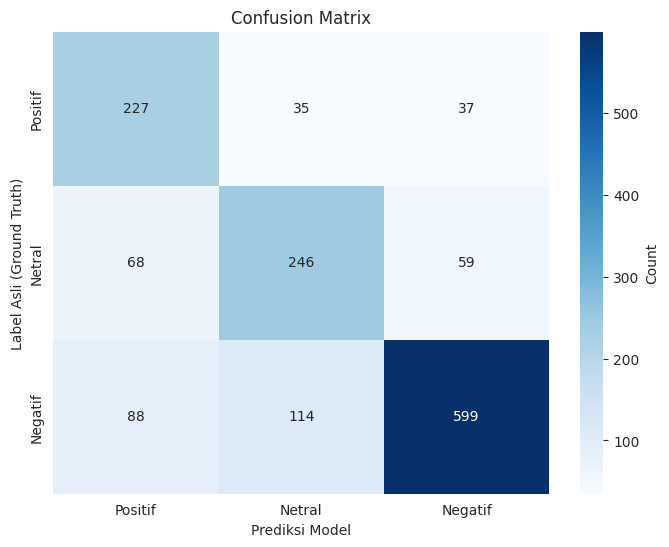

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class_labels = ['Positif', 'Netral', 'Negatif']

# ========================================
# NAIVE BAYES - TRAINING
# ========================================
print("="*60)
print("NAIVE BAYES - TRAINING")
print("="*60)

# Instantiate MultinomialNB model
mnb_model = MultinomialNB(alpha=1.0)

# Train the model using training data
print("Training Naive Bayes...")
mnb_model.fit(X_train_tfidf, y_train)

# Make predictions on test data
print("Making predictions on test data...")
y_pred_mnb = mnb_model.predict(X_test_tfidf)

print("="*60)
print()

# ========================================
# EVALUATION
# ========================================
print("="*60)
print("NAIVE BAYES - EVALUATION RESULTS")
print("="*60)

# Calculate metrics
conf_matrix_mnb = confusion_matrix(y_test, y_pred_mnb)
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)

# Classification Report dengan target_names yang sudah didefinisikan
class_report_mnb = classification_report(y_test, y_pred_mnb, target_names=class_labels)

print("\n✅ Accuracy: {:.4f} ({:.2f}%) ".format(accuracy_mnb, accuracy_mnb*100))
print()
print("Classification Report:")
print(class_report_mnb)
print()

# ========================================
# VISUALISASI CONFUSION MATRIX
# ========================================
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_mnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Asli (Ground Truth)')
plt.show()

In [ ]:
import pandas as pd

# Assuming y_test and y_pred are already available from model evaluation
# Assuming X_test is also available from the initial data splitting
# Assuming df is the original DataFrame and indices_test contains the original indices of the test set

# Define the mapping from numerical labels to sentiment names
# Based on your specified mapping: 0: Negatif, 1: Netral, 2: Positif
numerical_to_label = {0: 'Positif', 1: 'Netral', 2: 'Negatif'}

# Convert numerical labels back to original sentiment names
actual_sentiment = [numerical_to_label[label] for label in y_test]
predicted_sentiment = [numerical_to_label[label] for label in y_pred_mnb]

# Fix: Get the original indices of the test set from the test_df DataFrame
indices_test = test_df.index

# Get the original text using the test set indices
original_text = df.loc[indices_test, 'text'].tolist()

# Create a DataFrame
results_df_sentiment_names = pd.DataFrame({
    'Original_Text': original_text,
    'Actual_Label': actual_sentiment,
    'Predicted_Label': predicted_sentiment
})

# Display the first few rows of the DataFrame
print("DataFrame with Actual vs Predicted Sentiment Names and Original Text:")
display(results_df_sentiment_names.head())

# Optional: Display rows where actual and predicted labels differ
print("\nExamples where Actual and Predicted Labels Differ:")
display(results_df_sentiment_names[results_df_sentiment_names['Actual_Label'] != results_df_sentiment_names['Predicted_Label']].head())


# Define the path to save the CSV file
# Make sure the directory exists and you have write permissions
csv_save_path_sentiment_names = '/content/drive/MyDrive/Skripsi/Hasil_Predictions_Naive Bayes.csv' # Changed filename

# Save the DataFrame to a CSV file
results_df_sentiment_names.to_csv(csv_save_path_sentiment_names, index=False)

print(f"\nDataFrame saved to: {csv_save_path_sentiment_names}")

DataFrame with Actual vs Predicted Sentiment Names and Original Text:


,Original_Text,Actual_Label,Predicted_Label
0,dukung program makan bergizi gratis anakanak P...,Positif,Positif
1,pertumbuhan didukung asupan gizi baiklanjutkan...,Netral,Positif
2,update mbg teman-teman siswa berangkat deh,Netral,Positif
3,mbg iya bahasa beliau klpk umur,Netral,Positif
4,nomer call center email dm laporan pengaduan p...,Positif,Positif



Examples where Actual and Predicted Labels Differ:


,Original_Text,Actual_Label,Predicted_Label
1,pertumbuhan didukung asupan gizi baiklanjutkan...,Netral,Positif
2,update mbg teman-teman siswa berangkat deh,Netral,Positif
3,mbg iya bahasa beliau klpk umur,Netral,Positif
5,yaampun kedelai impor gandum tertawa prabowo p...,Netral,Positif
8,mbg ntb libur sekolah menyediakan makanan berg...,Positif,Netral



DataFrame saved to: /content/drive/MyDrive/Skripsi/Hasil_Predictions_Naive Bayes.csv


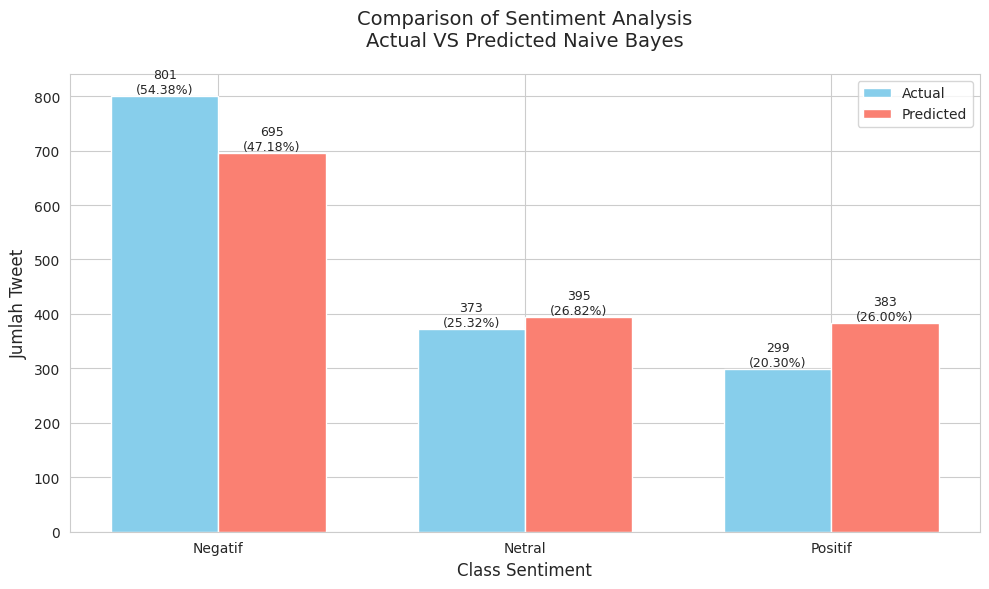

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use the results_df_sentiment_names DataFrame created earlier
# Compare Actual vs Predicted counts using results_df_sentiment_names
# We need to get counts for each sentiment name
actual_sentiment_counts = results_df_sentiment_names['Actual_Label'].value_counts()
predicted_sentiment_counts = results_df_sentiment_names['Predicted_Label'].value_counts()

# Define the desired order of labels for the plot
sentiment_labels_ordered = ['Negatif', 'Netral', 'Positif']

# Reindex the counts to ensure consistent order for plotting
actual_sentiment_counts = actual_sentiment_counts.reindex(sentiment_labels_ordered, fill_value=0)
predicted_sentiment_counts = predicted_sentiment_counts.reindex(sentiment_labels_ordered, fill_value=0)


comparison_df_sentiment = pd.DataFrame({
    'Actual': actual_sentiment_counts,
    'Predicted': predicted_sentiment_counts
})

# Create Plot
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = range(len(comparison_df_sentiment))

# Plot Actual
ax.bar([i - bar_width / 2 for i in index], comparison_df_sentiment['Actual'], width=bar_width, label='Actual', color='skyblue')

# Plot Predicted
ax.bar([i + bar_width / 2 for i in index], comparison_df_sentiment['Predicted'], width=bar_width, label='Predicted', color='salmon')

# Set labels and title
ax.set_xlabel('Class Sentiment', fontsize=12)
ax.set_ylabel('Jumlah Tweet', fontsize=12)
ax.set_title('Comparison of Sentiment Analysis\nActual VS Predicted Naive Bayes', fontsize=14, pad=20) # Update title
ax.set_xticks(index)
# Use sentiment names for ticks based on the ordered list
ax.set_xticklabels(sentiment_labels_ordered)
ax.legend()

# Add counts and percentages above bars
for i in index:
    actual_count = comparison_df_sentiment['Actual'].iloc[i]
    predicted_count = comparison_df_sentiment['Predicted'].iloc[i]

    actual_percentage = f'({(actual_count / comparison_df_sentiment["Actual"].sum()) * 100:.2f}%)' if comparison_df_sentiment["Actual"].sum() > 0 else '(0.00%)'
    predicted_percentage = f'({(predicted_count / comparison_df_sentiment["Predicted"].sum()) * 100:.2f}%)' if comparison_df_sentiment["Predicted"].sum() > 0 else '(0.00%)'

    ax.text(i - bar_width / 2, actual_count + 0.01, f'{int(actual_count)}\n{actual_percentage}', ha='center', va='bottom', fontsize=9)
    ax.text(i + bar_width / 2, predicted_count + 0.01, f'{int(predicted_count)}\n{predicted_percentage}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Prepare Probability Predictions and Binarize Labels


In [ ]:
from sklearn.preprocessing import label_binarize

# 1. Calculate predicted probabilities for each class
y_score_mnb = mnb_model.predict_proba(X_test_tfidf)

# 2. Binarize y_test for multiclass ROC calculation
# Mapping used: 0: Positif, 1: Netral, 2: Negatif
n_classes = 3
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

print(f"Shape of y_score_mnb: {y_score_mnb.shape}")
print(f"Shape of y_test_bin: {y_test_bin.shape}")
print("Probability preparation and label binarization complete.")

Shape of y_score_mnb: (1473, 3)
Shape of y_test_bin: (1473, 3)
Probability preparation and label binarization complete.


# Calculate and Visualize ROC-AUC Performance




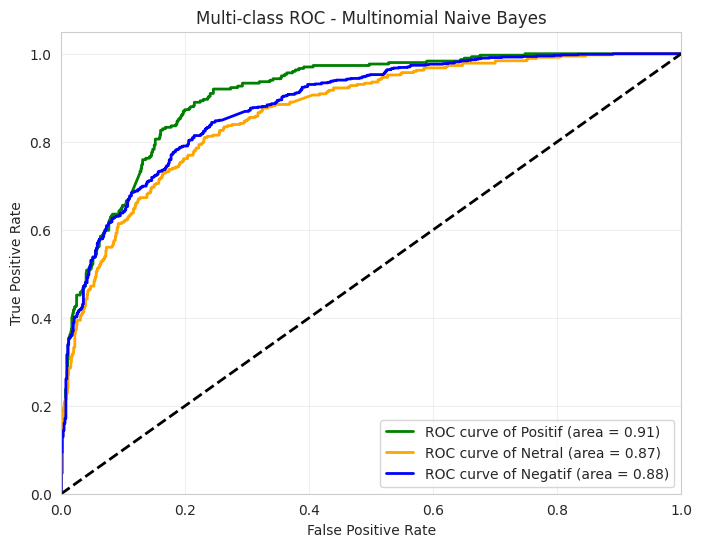

Summary of ROC-AUC Performance:
 - Positif: AUC = 0.9071
 - Netral: AUC = 0.8671
 - Negatif: AUC = 0.8829


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Define class names mapping for legend
class_names = {0: 'Positif', 1: 'Netral', 2: 'Negatif'}
fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC curve and ROC area for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_mnb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
colors = ['green', 'orange', 'blue']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC - Multinomial Naive Bayes')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Print Summary Findings
print("Summary of ROC-AUC Performance:")
for i in range(n_classes):
    print(f" - {class_names[i]}: AUC = {roc_auc[i]:.4f}")

# Calculate and Visualize Precision-Recall AUC (PR-AUC)

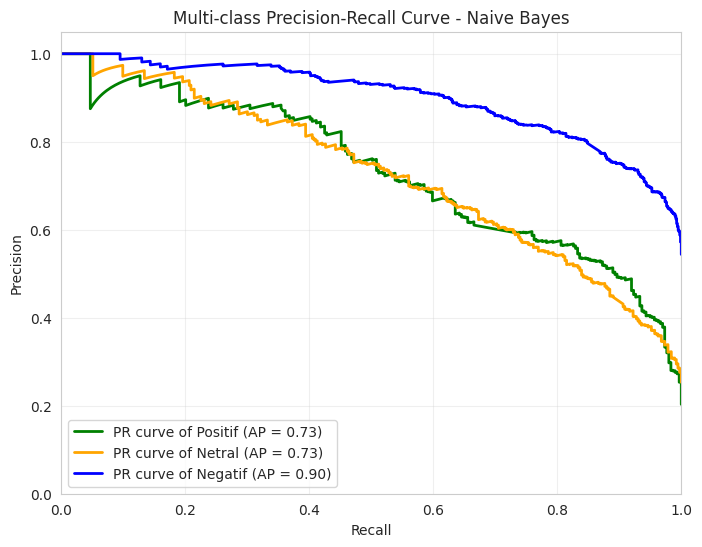

Summary of Average Precision (PR-AUC) Performance:
 - Positif: AP = 0.7307
 - Netral: AP = 0.7259
 - Negatif: AP = 0.8988


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Mapping nama kelas
class_names = {0: 'Positif', 1: 'Netral', 2: 'Negatif'}
precision = dict()
recall = dict()
average_precision = dict()

# 1. Hitung Precision-Recall curve dan Average Precision untuk setiap kelas
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score_mnb[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_score_mnb[:, i])

# 2. Plot PR Curves
plt.figure(figsize=(8, 6))
colors = ['green', 'orange', 'blue']

for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label=f'PR curve of {class_names[i]} (AP = {average_precision[i]:0.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Multi-class Precision-Recall Curve - Naive Bayes')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

# 3. Ringkasan Performa AP
print("Summary of Average Precision (PR-AUC) Performance:")
for i in range(n_classes):
    print(f" - {class_names[i]}: AP = {average_precision[i]:.4f}")